In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Makes plots show inside the notebook
%matplotlib inline



In [3]:
# Change the filename to match your downloaded CSV
df = pd.read_csv(r"C:\Users\Asus\Desktop\jobs_in_data.csv")

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
df.head(3)

Shape: (9355, 12)

Columns: ['work_year', 'job_title', 'job_category', 'salary_currency', 'salary', 'salary_in_usd', 'employee_residence', 'experience_level', 'employment_type', 'work_setting', 'company_location', 'company_size']

First 3 rows:


,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,2023,Data DevOps Engineer,Data Engineering,EUR,88000,95012,Germany,Mid-level,Full-time,Hybrid,Germany,L
1,2023,Data Architect,Data Architecture and Modeling,USD,186000,186000,United States,Senior,Full-time,In-person,United States,M
2,2023,Data Architect,Data Architecture and Modeling,USD,81800,81800,United States,Senior,Full-time,In-person,United States,M


In [4]:
print("=== Dataset Info ===")
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nData types:")
print(df.dtypes)

=== Dataset Info ===
Total rows: 9355
Total columns: 12

Missing values:
work_year             0
job_title             0
job_category          0
salary_currency       0
salary                0
salary_in_usd         0
employee_residence    0
experience_level      0
employment_type       0
work_setting          0
company_location      0
company_size          0
dtype: int64

Data types:
work_year             int64
job_title               str
job_category            str
salary_currency         str
salary                int64
salary_in_usd         int64
employee_residence      str
experience_level        str
employment_type         str
work_setting            str
company_location        str
company_size            str
dtype: object


In [5]:
# Look at each column's unique values
for col in df.columns:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count} unique values")
    if unique_count < 20:
        print(f"  Values: {df[col].unique()[:10]}")
    print()

work_year: 4 unique values
  Values: [2023 2022 2020 2021]

job_title: 125 unique values

job_category: 10 unique values
  Values: <StringArray>
[              'Data Engineering', 'Data Architecture and Modeling',
      'Data Science and Research',        'Machine Learning and AI',
                  'Data Analysis',      'Leadership and Management',
           'BI and Visualization',    'Data Quality and Operations',
   'Data Management and Strategy',             'Cloud and Database']
Length: 10, dtype: str

salary_currency: 11 unique values
  Values: <StringArray>
['EUR', 'USD', 'GBP', 'CAD', 'AUD', 'PLN', 'BRL', 'TRY', 'CHF', 'SGD']
Length: 10, dtype: str

salary: 1507 unique values

salary_in_usd: 1786 unique values

employee_residence: 83 unique values

experience_level: 4 unique values
  Values: <StringArray>
['Mid-level', 'Senior', 'Executive', 'Entry-level']
Length: 4, dtype: str

employment_type: 4 unique values
  Values: <StringArray>
['Full-time', 'Part-time', 'Contract', 'Fr

=== Salary by Category (USD) ===
                                    mean    median     min     max  count
job_category                                                             
Machine Learning and AI         178926.0  176000.0   15000  423000   1428
Data Science and Research       163759.0  159100.0   16000  450000   3014
Data Architecture and Modeling  156002.0  150000.0   52500  376080    259
Cloud and Database              155000.0  160000.0  115000  190000      5
Data Engineering                146198.0  139930.0   18000  385000   2260
Leadership and Management       145476.0  138750.0   20000  430640    503
BI and Visualization            135092.0  130000.0   15000  259900    313
Data Analysis                   108506.0  105000.0   15000  430967   1457
Data Management and Strategy    103140.0   90000.0   46400  250000     61
Data Quality and Operations     100879.0   82000.0   23753  289120     55


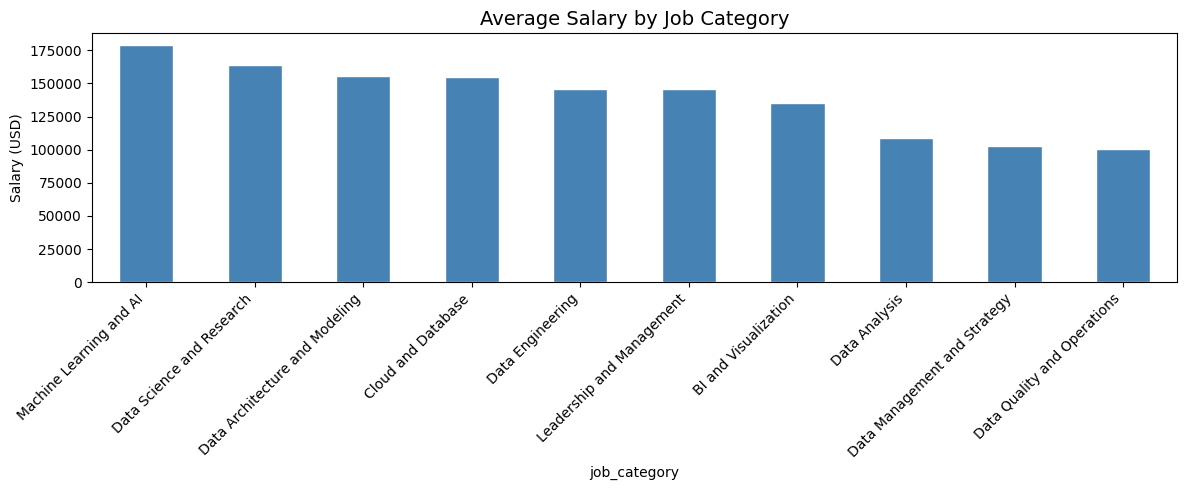

✅ Chart saved


In [9]:
# Salary distribution by job category
salary_by_cat = df.groupby('job_category')['salary_in_usd'].agg(
    ['mean', 'median', 'min', 'max', 'count']
).round(0).sort_values('mean', ascending=False)

print("=== Salary by Category (USD) ===")
print(salary_by_cat)

# Plot
plt.figure(figsize=(12, 5))
salary_by_cat['mean'].plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Average Salary by Job Category', fontsize=14)
plt.ylabel('Salary (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

import os
os.makedirs('../data', exist_ok=True)

plt.savefig('../data/salary_by_category.png')
plt.show()
print("✅ Chart saved")

In [ ]:
# Experience level distribution
exp_counts = df['experience_level'].value_counts()
exp_labels = {'EN': 'Entry', 'MI': 'Mid', 'SE': 'Senior', 'EX': 'Executive'}
exp_counts.index = [exp_labels.get(x, x) for x in exp_counts.index]

plt.figure(figsize=(8, 4))
exp_counts.plot(kind='bar', color=['#10b981', '#3b82f6', '#8b5cf6', '#f59e0b'])
plt.title('Jobs by Experience Level', fontsize=14)
plt.ylabel('Number of Jobs')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Salary by experience
salary_by_exp = df.groupby('experience_level')['salary_in_usd'].mean().round(0)
salary_by_exp.index = [exp_labels.get(x, x) for x in salary_by_exp.index]
print("\n=== Average Salary by Experience (USD) ===")
print(salary_by_exp.sort_values(ascending=False))